# Ablation report

| Table | Question | Source file |
|---|---|---|
| 1 | which backbone is best? | `output/backbone/per_unit.csv` |
| 2 | which regressor is best? | `output/ablation_report/raw_all.csv` |
| 3 | does anchoring on GIAA close the gap, and at what support size? | `output/ablation_report/raw_all.csv` |

**The two things we mainly care**:
1. does **Hybrid beat Population**
2. how closer the gap is between **Hybrid and Direct** 

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
from scipy.stats import wilcoxon
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
RAW = ROOT / "output" / "raw_all.csv"
BB = ROOT / "output" / "backbone" / "per_unit.csv"

UNIT = ["fold", "domain", "user_id"]   # one evaluation unit = one user in one domain
print(ROOT)
assert RAW.exists() and BB.exists(), "run: python -m src.experiments.make_raw_all"

D:\Pin\STUDY\0CU\แลกเปลี่ยน\JAIST Internship2025\PUBLISH\piaa-emotion-mediated


In [2]:
def collapse_seeds(d):
    #average across seeds.
    return d.groupby(["mediator"] + UNIT, as_index=False)["srocc"].mean()


def paired_p(d, med_a, med_b):
    """Paired Wilcoxon between two mediators on the units where both exist.

    Returns nan when the test is not defined (fewer than 5 pairs, or every
    difference is exactly zero), so a nan means 'no test', never 'not
    significant'.
    """
    s = collapse_seeds(d)
    a = s[s.mediator == med_a].set_index(UNIT)["srocc"]
    b = s[s.mediator == med_b].set_index(UNIT)["srocc"]
    j = pd.concat([a.rename("a"), b.rename("b")], axis=1).dropna()
    if len(j) < 5 or np.allclose(j.a, j.b):
        return np.nan
    return wilcoxon(j.a, j.b, method="approx").pvalue


def stat(d, med):
    """(mean, sem, n_units) for one mediator."""
    s = collapse_seeds(d)
    v = s[s.mediator == med]["srocc"].dropna()
    if len(v) == 0:
        return np.nan, np.nan, 0
    return v.mean(), v.std(ddof=1) / np.sqrt(len(v)), len(v)


def sig_mark(d, med, ref):
    """Dagger when `med` differs significantly from `ref` (paired Wilcoxon).

    The dagger marks a significant *difference*, in either direction. It is
    not a win marker: compare the two means to see which way it goes. Under
    variant B at 10 and 25 ratings, for example, the daggered Hybrid cell is
    significantly *below* Population.
    """
    if med == ref:
        return ""
    p = paired_p(d, med, ref)
    return "†" if (np.isfinite(p) and p < 0.05) else ""


def cell(d, med, vs=None):
    """'mean±sem', daggered if significantly different from `vs`."""
    m, sem, n = stat(d, med)
    if n == 0:
        return "-"
    txt = f"{m:.4f}±{sem:.4f}"
    if vs is not None:
        txt += sig_mark(d, med, vs)
    return txt


MEDS = [("population", "Population"), ("identity", "Direct"), ("emotion", "Hybrid")]

# Table 1 — which backbone is best?

100 ratings, ridge, plain. Population / Direct / Hybrid on all four backbones,
scored on the same 386 units.

`†` = significantly different from Population (paired Wilcoxon, p<0.05).
The dagger marks a difference in either direction — compare the means to see
which way. No Hybrid cell is daggered here: **no backbone lets Hybrid beat
Population significantly.**

In [3]:
bb = pd.read_csv(BB)
bb = bb[bb["head"] == "ridge"]

rows = []
for name in ["clip", "qwen4b", "qwen8b", "clip_ft"]:
    d = bb[bb.backbone == name]
    pop_m, _, n_units = stat(d, "population")
    dir_m, _, _ = stat(d, "identity")
    hyb_m, _, _ = stat(d, "emotion")
    rows.append({
        "backbone": name,
        "Population": cell(d, "population"),
        "Direct": cell(d, "identity", vs="population"),
        "Hybrid": cell(d, "emotion", vs="population"),
        "Hybrid-Pop": round(hyb_m - pop_m, 4),
        "Hybrid-Direct": round(hyb_m - dir_m, 4),
        "p(Hyb vs Pop)": round(paired_p(d, "emotion", "population"), 4),
    })

table1 = pd.DataFrame(rows)
table1

,backbone,Population,Direct,Hybrid,Hybrid-Pop,Hybrid-Direct,p(Hyb vs Pop)
0,clip,0.4174±0.0092,0.4009±0.0100†,0.4200±0.0094,0.0027,0.0192,0.7905
1,qwen4b,0.4359±0.0090,0.4150±0.0094†,0.4357±0.0090,-0.0003,0.0207,0.3025
2,qwen8b,0.4395±0.0091,0.4269±0.0094†,0.4462±0.0089,0.0067,0.0193,0.6159
3,clip_ft,0.4140±0.0091,0.4468±0.0092†,0.4254±0.0090,0.0115,-0.0214,0.0881


# Table 2 — which regressor is best?

CLIP, plain, 100 ratings. Ridge vs Lasso vs ElasticNet, on CLIP's own 387 units.

The last two columns measure how steady the Hybrid score is:
- **SD across users** — spread of the per-user scores
- **SD across folds** — how much the mean moves between the 5 train/test splits

In [4]:
raw = pd.read_csv(RAW)
t2src = raw[(raw.backbone == "clip") & (raw.variant == "plain") & (raw.n_train == 100)]

rows = []
for head in ["ridge", "lasso", "elastic"]:
    d = t2src[t2src["head"] == head]
    pop_m, _, _ = stat(d, "population")
    dir_m, _, _ = stat(d, "identity")
    hyb_m, _, _ = stat(d, "emotion")

    # stability of the Hybrid row: how much the score moves if you change
    # who you asked (across users) or how you split the data (across folds)
    hyb = collapse_seeds(d[d.mediator == "emotion"]).dropna(subset=["srocc"])
    sd_users = hyb["srocc"].std(ddof=1)
    sd_folds = hyb.groupby("fold")["srocc"].mean().std(ddof=1)

    rows.append({
        "head": head,
        "Population": cell(d, "population"),
        "Direct": cell(d, "identity", vs="population"),
        "Hybrid": cell(d, "emotion", vs="population"),
        "Hybrid-Pop": round(hyb_m - pop_m, 4),
        "Hybrid-Direct": round(hyb_m - dir_m, 4),
        "p(Hyb vs Pop)": round(paired_p(d, "emotion", "population"), 4),
        "SD across users": round(sd_users, 4),
        "SD across folds": round(sd_folds, 4),
    })

table2 = pd.DataFrame(rows)
table2

,head,Population,Direct,Hybrid,Hybrid-Pop,Hybrid-Direct,p(Hyb vs Pop),SD across users,SD across folds
0,ridge,0.4159±0.0091,0.3998±0.0099†,0.4187±0.0093,0.0028,0.0189,0.8416,0.1831,0.0126
1,lasso,0.4117±0.0090,0.3297±0.0101†,0.4178±0.0093,0.0061,0.0882,0.4564,0.1835,0.0150
2,elastic,0.4117±0.0090,0.3445±0.0102†,0.4189±0.0092,0.0072,0.0744,0.1681,0.1812,0.0135


## How spread out are the per-user results?

The means above hide what happens to individual users. These histograms show
every user-domain unit, so the shape of the distribution is visible rather
than just its centre.

**Left** — per-user SROCC for Hybrid under each regressor. Answers "is one
regressor more consistent than the others?"

**Right** — per-user (Hybrid − Population) under each anchor variant. This is
the quantity the significance test actually looks at: the paper's claim needs
this distribution to sit clearly to the right of zero, not just to have a
positive mean. The dashed line is zero, and the legend gives the share of
users on the winning side.

saved fig_distributions.png


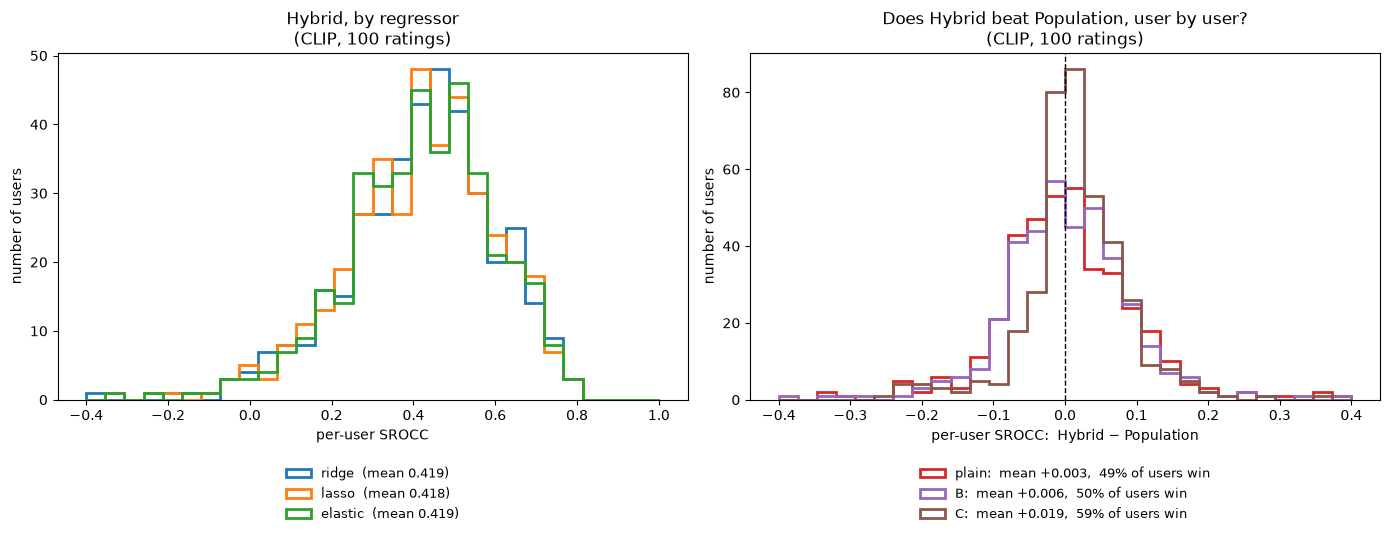

In [5]:
import matplotlib.pyplot as plt

# CLIP + ridge across every anchor variant and support size (also used by Table 3)
t3src = raw[(raw.backbone == "clip") & (raw["head"] == "ridge")]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.6))

# --- left: per-user SROCC of Hybrid, one line per regressor ---------------
for head, colour in [("ridge", "C0"), ("lasso", "C1"), ("elastic", "C2")]:
    d = t2src[(t2src["head"] == head) & (t2src.mediator == "emotion")]
    v = collapse_seeds(d)["srocc"].dropna()
    ax1.hist(v, bins=30, range=(-0.4, 1.0), histtype="step", lw=2,
             color=colour, label=f"{head}  (mean {v.mean():.3f})")
ax1.set_xlabel("per-user SROCC")
ax1.set_ylabel("number of users")
ax1.set_title("Hybrid, by regressor\n(CLIP, 100 ratings)")

# --- right: per-user (Hybrid - Population), one line per anchor variant ---
for variant, colour in [("plain", "C3"), ("B", "C4"), ("C", "C5")]:
    d = t3src[(t3src.variant == variant) & (t3src.n_train == 100)]
    s = collapse_seeds(d)
    h = s[s.mediator == "emotion"].set_index(UNIT)["srocc"]
    p = s[s.mediator == "population"].set_index(UNIT)["srocc"]
    diff = (h - p).dropna()
    if diff.empty:
        continue
    win = 100 * (diff > 0).mean()
    ax2.hist(diff, bins=30, range=(-0.4, 0.4), histtype="step", lw=2,
             color=colour,
             label=f"{variant}:  mean {diff.mean():+.3f},  {win:.0f}% of users win")
ax2.axvline(0, ls="--", c="k", lw=1)
ax2.set_xlabel("per-user SROCC:  Hybrid − Population")
ax2.set_ylabel("number of users")
ax2.set_title("Does Hybrid beat Population, user by user?\n(CLIP, 100 ratings)")

# legends below each panel so they never sit on top of the bars
for ax in (ax1, ax2):
    ax.legend(frameon=False, loc="upper center", bbox_to_anchor=(0.5, -0.16),
              ncol=1, fontsize=9)

plt.tight_layout()
FIG = ROOT / "output" / "ablation_report" / "fig_distributions.png"
plt.savefig(FIG, dpi=150, bbox_inches="tight")
print("saved", FIG.name)
plt.show()

# Table 3 — does anchoring on GIAA close the gap?

CLIP, ridge. Rows = Population / Direct / Hybrid. Columns = anchor variant ×
support size.
(I missed the 100-support size in A)

- **plain** — ordinary ridge, shrinks toward zero
- **A** — GIAA prediction added as an extra feature
- **B** — weights shrink toward the pooled training-group weights
- **C** — head is fit on the residual `y − y_pop`

`†` = significantly different from Population at the same variant and n
(paired Wilcoxon, p<0.05).

**The dagger marks a difference, not a win — check which mean is larger.**
Under **B**, the daggered Hybrid cells at 10 and 25 ratings are significantly
*below* Population (0.404 and 0.405 vs 0.416). The only cell where Hybrid is
significantly *above* Population is **C at 100 ratings** (0.436 vs 0.417).

In [6]:
recs = []
for variant in ["plain", "A", "B", "C"]:
    for n_train in [10, 25, 50, 100]:
        d = t3src[(t3src.variant == variant) & (t3src.n_train == n_train)]
        if d.empty:
            continue
        for med, label in MEDS:
            m, se, n_units = stat(d, med)
            recs.append({
                "variant": variant, "n_train": n_train, "mediator": label,
                "srocc": m, "sem": se,
                "mark": sig_mark(d, med, "population"),
            })

t3 = pd.DataFrame(recs)
order = [(v, n) for v in ["plain", "A", "B", "C"] for n in [10, 25, 50, 100]]
table3 = t3.pivot_table(index="mediator", columns=["variant", "n_train"],
                        values="srocc")
table3 = table3.reindex(["Population", "Direct", "Hybrid"])
table3 = table3.reindex(columns=pd.MultiIndex.from_tuples(
    [c for c in order if c in table3.columns]))
table3.round(4)

plain                               A                       B  \
               10      25      50      100     10      25      50      10    
mediator                                                                     
Population  0.4159  0.4159  0.4159  0.4159  0.4159  0.4159  0.4159  0.4159   
Direct      0.2231  0.2929  0.3473  0.3998  0.2291  0.2989  0.3543  0.4196   
Hybrid      0.3255  0.3795  0.4038  0.4187  0.3391  0.3900  0.4151  0.4041   

                                         C                          
               25      50      100     10      25      50      100  
mediator                                                            
Population  0.4159  0.4159  0.4174  0.4159  0.4159  0.4159  0.4174  
Direct      0.4312  0.4404  0.4576  0.4196  0.4312  0.4404  0.4576  
Hybrid      0.4047  0.4138  0.4233  0.4138  0.4152  0.4232  0.4363

In [7]:
# same table, formatted as mean±sem with the direction marker
# bracket access, not r.sem / r.srocc: a Series has a .sem() method, so r.sem
# returns that method instead of the column (same trap as df.head)
def fmt_row(r):
    return f"{r['srocc']:.3f}±{r['sem']:.3f}" + r["mark"]

t3["cell"] = t3.apply(fmt_row, axis=1)
table3_fmt = t3.pivot_table(index="mediator", columns=["variant", "n_train"],
                            values="cell", aggfunc="first")
table3_fmt = table3_fmt.reindex(["Population", "Direct", "Hybrid"])
table3_fmt = table3_fmt.reindex(columns=pd.MultiIndex.from_tuples(
    [c for c in order if c in table3_fmt.columns]))
table3_fmt

plain                                            \
                     10            25            50            100   
mediator                                                             
Population   0.416±0.009   0.416±0.009   0.416±0.009   0.416±0.009   
Direct      0.223±0.011†  0.293±0.011†  0.347±0.010†  0.400±0.010†   
Hybrid      0.325±0.013†  0.380±0.011†  0.404±0.009†   0.419±0.009   

                       A                                         B  \
                     10            25            50            10    
mediator                                                             
Population   0.416±0.009   0.416±0.009   0.416±0.009   0.416±0.009   
Direct      0.229±0.011†  0.299±0.011†  0.354±0.010†  0.420±0.009†   
Hybrid      0.339±0.013†  0.390±0.010†   0.415±0.009  0.404±0.009†   

                                                                 C  \
                     25            50            100           10    
mediator                                                             
Population   0.416±0.009   0.416±0.009   0.417±0.009   0.416±0.009   
Direct      0.431±0.009†  0.440±0.009†  0.458±0.009†  0.420±0.009†   
Hybrid      0.405±0.009†   0.414±0.009   0.423±0.009   0.414±0.009   

                                                      
                     25            50            100  
mediator                                              
Population   0.416±0.009   0.416±0.009   0.417±0.009  
Direct      0.431±0.009†  0.440±0.009†  0.458±0.009†  
Hybrid       0.415±0.009   0.423±0.009  0.436±0.009†

In [8]:
OUT = ROOT / "output" / "ablation_report"
table1.to_csv(OUT / "table1_backbone.csv", index=False)
table2.to_csv(OUT / "table2_regressor.csv", index=False)
table3_fmt.to_csv(OUT / "table3_anchor.csv")
print("saved 3 tables + fig_distributions.png to", OUT)

saved 3 tables + fig_distributions.png to D:\Pin\STUDY\0CU\แลกเปลี่ยน\JAIST Internship2025\PUBLISH\piaa-emotion-mediated\output\ablation_report
